In [1]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
def compute_stall_boundary(V_min, V_max, n_points, rho_sl, CL_max, Weight, S_ref):
    print("Computing stall boundary...")
    stall_coeff = 0.5 * rho_sl * CL_max / (Weight / S_ref)
    print(f"W/S: {Weight / S_ref:.3f} lb/ft^2")
    print(f"Stall coefficient: {stall_coeff:.6f}")

    V = np.linspace(V_min, V_max, n_points)
    n_Stall = stall_coeff * V**2

    return V, n_Stall, stall_coeff

rho_sl = 0.002377    # slugs/ft^3 (sea level)
rho_30k = 0.000889   # slugs/ft^3 at 30,000 ft

V_max_TAS = 895     # ft/s calculated from (strike Mach 0.9 at 30,000 ft altitude ~ 895 ft/s/ a2a Mach 1.6 at 30,000 ft altitude ~ 1,592 ft/s)
V_max = V_max_TAS * np.sqrt(rho_30k / rho_sl)
V_min = 0            # ft/s

print(f"Converted V_max (EAS): {V_max:.2f} ft/s")

n_points = 100

CL_max = 1.2       # 1.2 or 1.6 (will confirm)

MTOW_lb = 0     # [set to 0 if doing min case] change for mission type (strike=36796.33) (a2a=33953.47)
minTOW_lb = 22489.32   # [set to 0 if doing max case] change for mission type (strike=22489.32) (a2a=22404.03)
Weight = MTOW_lb + minTOW_lb    # lbf
S_ref = 400   # ft^2 

# --- RUN ---
Boundary_V, Boundary_n_Stall, stall_coeff = compute_stall_boundary(
    V_min, V_max, n_points, rho_sl, CL_max, Weight, S_ref
)

V = np.linspace(V_min, V_max, n_points)


Converted V_max (EAS): 547.34 ft/s
Computing stall boundary...
W/S: 56.223 lb/ft^2
Stall coefficient: 0.000025


In [9]:
n_pos_limit = 8   # set to 7 or 8g according to goal
print(f"Positive limit load factor: {n_pos_limit:.2f}")

# Under MIL-A-8861
n_neg_limit = -0.4 * n_pos_limit
print(f"Negative limit load factor: {n_neg_limit:.2f}")

# Stall speed
V_s = np.sqrt(1 / stall_coeff)

# Maneuvering speed
V_A = np.sqrt(n_pos_limit / stall_coeff)

# Design cruising speed
V_C = 780.00

# Dive speed
V_D = 1.13 * V_C

# Wing loading
W_S = Weight / S_ref

# Maximum level flight speed
V_H_min = 33 * np.sqrt(W_S)
V_H_max = 0.9 * V_D
V_H = V_H_max

print(f"V_H min = {V_H_min:.2f} ft/s")
print(f"V_H max = {V_H_max:.2f} ft/s")
print(f"Selected V_H = {V_H:.2f} ft/s")

print(f"Vs = {V_s:.2f} ft/s")
print(f"VA = {V_A:.2f} ft/s")
print(f"VC = {V_C:.2f} ft/s")
print(f"VD = {V_D:.2f} ft/s")

Positive limit load factor: 8.00
Negative limit load factor: -3.20
V_H min = 247.44 ft/s
V_H max = 793.26 ft/s
Selected V_H = 793.26 ft/s
Vs = 198.55 ft/s
VA = 561.58 ft/s
VC = 780.00 ft/s
VD = 881.40 ft/s


In [10]:
def compute_intersection_velocity(stall_coeff, n_limit):
    """
    Solve stall_coeff * V^2 = |n_limit|
    """
    int_V = np.sqrt(abs(n_limit) / stall_coeff)
    print(f"Intersection velocity for n_limit={n_limit:.2f} is {int_V:.2f} ft/s")
    return int_V


# Compute intersection velocities
V_stall_pos_end = compute_intersection_velocity(stall_coeff, n_pos_limit)
V_stall_pos = np.linspace(0, V_stall_pos_end, 100)

V_stall_neg_end = compute_intersection_velocity(stall_coeff, n_neg_limit)
V_stall_neg = np.linspace(0, V_stall_neg_end, 100)

# Compute load factor curves
n_stall_pos_intersection = stall_coeff * V_stall_pos**2
n_stall_neg_intersection = -stall_coeff * V_stall_neg**2

Intersection velocity for n_limit=8.00 is 561.58 ft/s
Intersection velocity for n_limit=-3.20 is 355.18 ft/s


In [11]:
# Extend the positive limit load line to the right of the intersection point
V_pos_limit_extended = np.linspace(V_stall_pos_end, V_D, 100)
n_pos_extended = np.ones_like(V_pos_limit_extended) * n_pos_limit

V_neg_limit_extended = np.linspace(V_stall_neg_end, V_C, 100)
n_neg_extended = np.ones_like(V_neg_limit_extended) * n_neg_limit


In [11]:
# def compute_k_g(weight, lift_slope, S_ref, c_bar):
    # mu_g = 2*weight / (lift_slope * S_ref * c_bar)
    # k_g = 0.88 * mu_g /(1 + mu_g)
    # print(f"Computed k_g: {k_g:.3f} N/m^2 per unit CL")
    # print(f"Computed mu_g: {mu_g:.3f}")
    # return k_g

# b = 37.508          # ft, wingspan
# c_bar = S_ref / b  # ft, mean aerodynamic chord
# print(f"Computed mean aerodynamic chord: {c_bar:.3f} ft")

# lift_slope = 0     # 1/rad
# k_g = compute_k_g(Weight, lift_slope, S_ref, c_bar)

# def air_density_nasa_si(altitude_m):
#     if altitude_m < 0:
#         raise ValueError("Altitude must be non-negative.")

#     # Troposphere
#     if altitude_m <= 11000:
#         T = 15.04 - 0.00649 * altitude_m + 273.15   # K
#         p = 101290 * (T / 288.08) ** 5.256          # Pa

#     # Lower stratosphere
#     elif altitude_m <= 25000:
#         T = -56.46 + 273.15                         # K
#         p = 22650 * math.exp(1.73 - 0.000157 * altitude_m)   # Pa

#     else:
#         raise ValueError("This simplified NASA model here is set up only up to 25,000 m.")

#     rho = p / (287.05 * T)   # kg/m^3
#     return rho

# # def ft_per_s_to_m_per_s(speed_ft_s):
#     m_per_s = speed_ft_s * 0.3048
#     return m_per_s

# # def ft_to_m(altitude_ft):
#     altitude_m = altitude_ft * 0.3048
#     return altitude_m

# U_de_sl = ft_per_s_to_m_per_s(56)    # m/s
# U_de_15kft = ft_per_s_to_m_per_s(44)  # m/s
# U_de_50kft = ft_per_s_to_m_per_s(26)  # m/s
# print(f"Vertical gust velocity at sea level: {U_de_sl:.2f} m/s")
# print(f"Vertical gust velocity at 15,000 ft: {U_de_15kft:.2f} m/s")
# print(f"Vertical gust velocity at 50,000 ft: {U_de_50kft:.2f} m/s")

# U_de_sl_dive = U_de_sl * 0.5
# U_de_15kft_dive = U_de_15kft * 0.5
# U_de_50kft_dive = U_de_50kft * 0.5
# print(f"Vertical gust velocity at sea level during dive: {U_de_sl_dive:.2f} m/s")
# print(f"Vertical gust velocity at 15,000 ft during dive: {U_de_15kft_dive:.2f} m/s")
# print(f"Vertical gust velocity at 50,000 ft during dive: {U_de_50kft_dive:.2f} m/s")

# rho_sl = air_density_nasa_si(0)
# print(f"Air density at sea level: {rho_sl:.3f} kg/m^3")
# rho_15kft = air_density_nasa_si(ft_to_m(15000))
# print(f"Air density at 15,000 ft: {rho_15kft:.3f} kg/m^3")
# rho_50kft = air_density_nasa_si(ft_to_m(50000))
# print(f"Air density at 50,000 ft: {rho_50kft:.6f} kg/m^3")

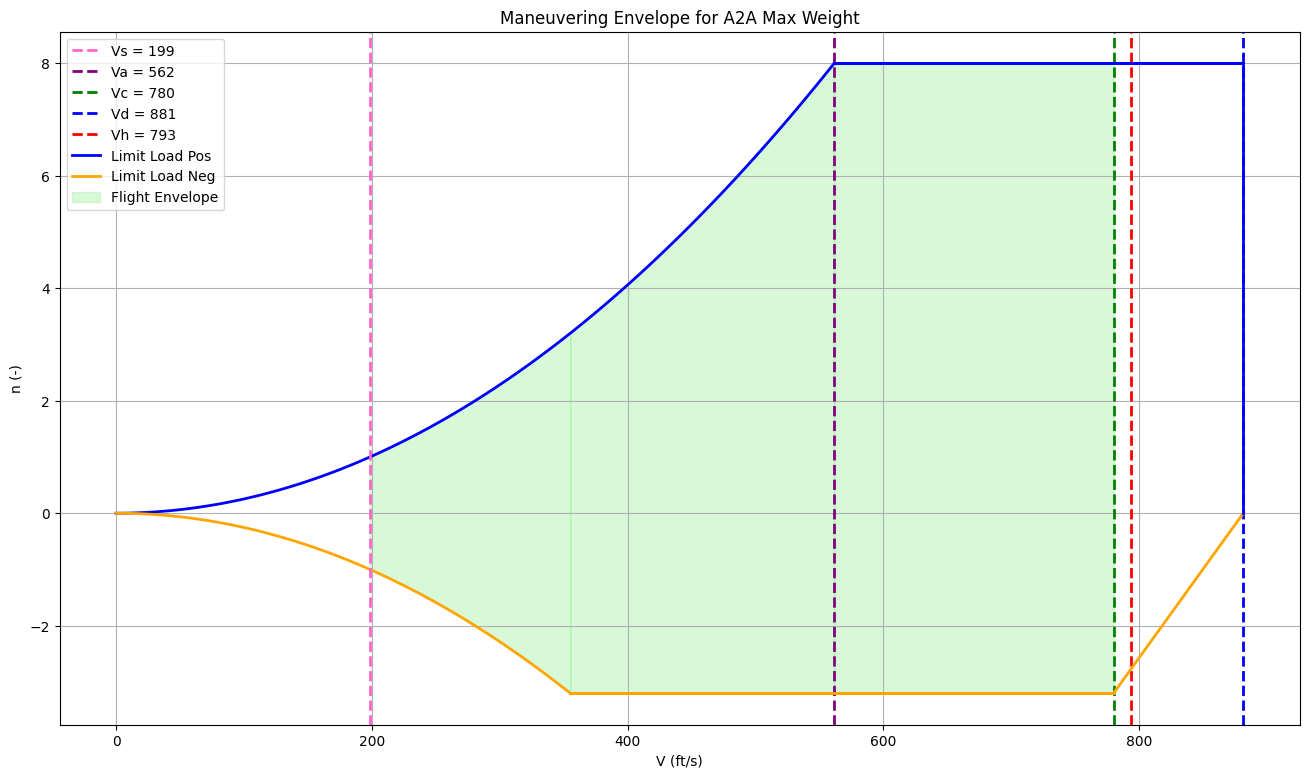

In [14]:
plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope for A2A Max Weight')
plt.xlabel("V (ft/s)")
plt.ylabel("n (-)")

plt.plot(V_stall_pos, n_stall_pos_intersection, linewidth=2, color='blue')
plt.plot(V_stall_neg, n_stall_neg_intersection, linewidth=2, color='orange')

plt.plot(V_pos_limit_extended, n_pos_extended, linewidth=2, color='blue')
plt.plot(V_neg_limit_extended, n_neg_extended, linewidth=2, color='orange')

# Characteristic speeds
plt.axvline(V_s, linestyle='--', color='#ff66cc', linewidth=2, label=f'Vs = {V_s:.0f}')
plt.axvline(V_A, linestyle='--', color='purple', linewidth=2, label=f'Va = {V_A:.0f}')
plt.axvline(V_C, linestyle='--', color='green', linewidth=2, label=f'Vc = {V_C:.0f}')
plt.axvline(V_D, linestyle='--', color='blue', linewidth=2, label=f'Vd = {V_D:.0f}')
plt.axvline(V_H, linestyle='--', color='red', linewidth=2, label=f'Vh = {V_H:.0f}')

# Connect negative line to VD
V_connect = np.linspace(V_C, V_D, 50)
n_connect = np.linspace(n_neg_limit, 0, 50)
plt.plot(V_connect, n_connect, linewidth=2, color='orange')

# Right vertical dive line
n_right = np.linspace(n_pos_limit, 0, 50)
V_right = np.full_like(n_right, V_D)
plt.plot(V_right, n_right, linewidth=2, color='blue')

plt.plot(
    V_pos_limit_extended,
    n_pos_extended,
    linewidth=2,
    color='blue',
    label='Limit Load Pos'
)

plt.plot(
    V_neg_limit_extended,
    n_neg_extended,
    linewidth=2,
    color='orange',
    label='Limit Load Neg'
)

# ---------------------------------------------------------
# SHADED FLIGHT ENVELOPE
# ---------------------------------------------------------

norm_shade = 'lightgreen'

# Region 1
V1 = np.linspace(V_s, V_stall_neg_end, 200)
plt.fill_between(
    V1,
    stall_coeff * V1**2,
    -stall_coeff * V1**2,
    color=norm_shade,
    alpha=0.35
)

# Region 2
V2 = np.linspace(V_stall_neg_end, V_stall_pos_end, 200)
plt.fill_between(
    V2,
    stall_coeff * V2**2,
    np.ones_like(V2) * n_neg_limit,
    color=norm_shade,
    alpha=0.35
)

# Region 3
V3 = np.linspace(V_stall_pos_end, V_C, 200)
plt.fill_between(
    V3,
    np.ones_like(V3) * n_pos_limit,
    np.ones_like(V3) * n_neg_limit,
    color=norm_shade,
    alpha=0.35,
    label='Flight Envelope'
)

plt.grid(True)
plt.legend()
plt.show()